# Scrambled Trajectory

In [1]:
0

0

In [2]:
import sys
working_directory = "/home/icb/kemal.inecik/work/codes/sctram"
sys.path.append(working_directory)
sys.path.append("/home/icb/kemal.inecik/work/codes/sctram/reproducibility/server_sync/experiments")

import logging
import subprocess
import gc
import os
import time
import numpy as np
import pandas as pd
import networkx as nx
import scanpy as sc
import anndata as ad
from sklearn.preprocessing import MinMaxScaler
from scipy.cluster.hierarchy import linkage, leaves_list
import scipy.stats as stats
import itertools

import scvelo as scv
import cellrank as cr
import scanpy.external as sce

scv.settings.verbosity = 3
cr.settings.verbosity = 2
sc.settings.verbose = 3

In [3]:
from sctram.api._lower_level import TrajectoryEvaluationAPI
from sctram.input import InputTrajectories
from sctram.generate.real import sc_suo_developmental_complete

from suo_across_models.helper.plot_obsms import plot_obsms
from incremental_training.helper.constants import metric_direction_dict, trajectory_classification_dict
from tardis_weight_scan.helper.plotting import plot_summary_ci, plot_umap_grid, normalize_and_align, annotate_points_on_line

2025-07-30 13:14:35.686 | INFO     | sctram.api._defaults_read:load_default_metrics:23 - Loaded default metrics from /home/icb/kemal.inecik/work/codes/sctram/sctram/api/_defaults.yaml
2025-07-30 13:14:35.687 | INFO     | sctram.api._defaults_read:load_default_metrics:79 - Default metrics YAML structure validated successfully.


In [4]:
# Important to have consistent figures across platforms

%matplotlib inline
%config InlineBackend.figure_format='retina'

import pickle

from networkx.drawing.nx_agraph import graphviz_layout
from matplotlib import gridspec
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import seaborn as sns
import colorcet as cc
from matplotlib.ticker import FormatStrFormatter
from adjustText import adjust_text  
import matplotlib.patheffects as path_effects

_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, "rb") as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

In [5]:
dataset_dir = "/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data"
helpers_directory = os.path.join(os.getcwd(), "helper")
logs_directory = os.path.join(os.getcwd(), "logs")

adata_suo_complete = sc_suo_developmental_complete(dataset_dir=dataset_dir)

2025-07-30 13:14:39.426 | WARNING  | sctram.generate.real._download:download_dataset:105 - File PosixPath('/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/suo_developmental_complete.h5ad') already exists. Skipping download.


# Load the data

In [6]:
input_trajectories_path_with_df = os.path.join(dataset_dir, f"scrambled_haematopoeitic_lineage_suo_trajectories_with_df.pkl")
with open(input_trajectories_path_with_df, "rb") as _file:
    lit, df_run = pickle.load(_file)

In [7]:
dict_run = dict()
for _, _row_df_run in df_run.iterrows():
    item = _row_df_run["new_trajectory_name"]
    if item not in dict_run:
        dict_run[item] = dict(
            amount = _row_df_run["amount"],
            accuracy = _row_df_run["accuracy"],
            trajectory_name = _row_df_run["trajectory_name"],
            seed = _row_df_run["seed"],
            index = _row_df_run["index"],
        )
    else:
        raise ValueError

In [8]:
n_neighbors = 50
lineages = ["Haematopoeitic_lineage"]

In [36]:
df = pd.DataFrame()
lineage = "Haematopoeitic_lineage"
for trajectory in sorted(lit.graph["trajectories"]):
    lineage_part = lineage.replace("_lineage", "").lower()
    for use_rep in ["scanvi", "tardis_2", "X_pca"]:
        output_file = os.path.join(dataset_dir, f"metric_sctram_suo_scrambling_{lineage_part}_{use_rep}_{trajectory}.pickle")
        df_trajectory_obsm = pd.read_pickle(output_file)
        df_trajectory_obsm["representation"] = use_rep
        df_trajectory_obsm["trajectory"] = trajectory
        df = pd.concat([df, df_trajectory_obsm])
df.reset_index(drop=True, inplace=True)
df['score'] = pd.to_numeric(df['score'], errors='raise')
df.sort_values(by=["trajectory", "path", "metric", "representation"], inplace=True, ignore_index=True)

df['trajectory_base'] = df['trajectory'].str.extract(r'^([a-zA-Z_]+)')
df['trajectory_base'] = df['trajectory_base'].str.rstrip('_')

assert len(set(df["trajectory_base"].unique()) - set(trajectory_classification_dict.keys())) == 0
df["trajectory_class"]= [trajectory_classification_dict[r["trajectory_base"]] for _, r in df.iterrows()]
assert set(df["metric"].unique()) == set(metric_direction_dict.keys())

df = df[['trajectory_base', 'trajectory_class', "trajectory", "path", "metric", "representation", "score"]]
df

,trajectory_base,trajectory_class,trajectory,path,metric,representation,score
0,b_cells,lymphoid,b_cells_1008,adjacency,accuracy,X_pca,0.801653
1,b_cells,lymphoid,b_cells_1008,adjacency,accuracy,scanvi,0.851240
2,b_cells,lymphoid,b_cells_1008,adjacency,accuracy,tardis_2,0.818182
3,b_cells,lymphoid,b_cells_1008,adjacency,average_shortest_path_difference,X_pca,3.518693
4,b_cells,lymphoid,b_cells_1008,adjacency,average_shortest_path_difference,scanvi,3.525090
...,...,...,...,...,...,...,...
38155,erythroid_megakaryocyte,mem,erythroid_megakaryocyte_1999,pseudotime,spearman_correlation,scanvi,0.561318
38156,erythroid_megakaryocyte,mem,erythroid_megakaryocyte_1999,pseudotime,spearman_correlation,tardis_2,0.500767
38157,erythroid_megakaryocyte,mem,erythroid_megakaryocyte_1999,pseudotime,wasserstein_distance_pseudotime,X_pca,0.529541
38158,erythroid_megakaryocyte,mem,erythroid_megakaryocyte_1999,pseudotime,wasserstein_distance_pseudotime,scanvi,0.521376


In [37]:
df_with_run = []
for _, row in df.iterrows():
    rtd = row.to_dict()
    rtd.update(dict_run[row["trajectory"]])
    df_with_run.append(rtd)

In [38]:
col_map = {
    "trajectory_name":   "trajectory_name",
    "trajectory":        "trajectory_name_scrambling",    
    "path":              "path",
    "metric":            "metric",
    "representation":    "representation",
    "score":             "score",
    "amount":            "scrambling_amount",
    "accuracy":          "scrambling_accuracy",
    "seed":              "scrambling_seed",
    "index":             "scrambling_index"
}
df_sctram = pd.DataFrame(df_with_run).rename(columns=col_map)
sort_columns_by = [
    "trajectory_class",
    "trajectory_base",
    "trajectory_name",
    "trajectory_name_scrambling",
    "scrambling_index",
    "scrambling_amount",
    "scrambling_accuracy",
    "scrambling_seed",
    "path",
    "metric",
    "representation",
    "score"
]
df_sctram = df_sctram[sort_columns_by]

df_sctram['score'] = pd.to_numeric(df_sctram['score'], errors='raise')
df_sctram['scrambling_seed'] = pd.to_numeric(df_sctram['scrambling_seed'], errors='raise')
df_sctram['scrambling_accuracy'] = pd.to_numeric(df_sctram['scrambling_accuracy'], errors='raise')
df_sctram['scrambling_amount'] = pd.to_numeric(df_sctram['scrambling_amount'], errors='raise')
df_sctram['scrambling_index'] = pd.to_numeric(df_sctram['scrambling_index'], errors='raise')
assert set(df_sctram["metric"].unique()) == set(metric_direction_dict.keys())

df_sctram.sort_values(by=sort_columns_by, inplace=True, ignore_index=True)
df_sctram.reset_index(drop=True, inplace=True)

loaded_runs_path = os.path.join(dataset_dir, f"scrambling_trajectories_experiment_sctram_on_suo.pkl")
with open(loaded_runs_path, "wb") as _f:
    pickle.dump(df_sctram, _f, protocol=pickle.HIGHEST_PROTOCOL)

# Analysis

In [43]:
loaded_runs_path = os.path.join(dataset_dir, f"scrambling_trajectories_experiment_sctram_on_suo.pkl")
with open(loaded_runs_path, "rb") as _loaded_runs_path:
    df_sctram = pickle.load(_loaded_runs_path) 

In [44]:
len(np.unique(df_sctram["trajectory_name_scrambling"])) * 3

795

In [45]:
df_result = df_sctram.groupby("trajectory_name", group_keys=False).apply(
    lambda g: normalize_and_align(g, metric_direction_dict), include_groups=True
).reset_index(drop=True)

In [150]:
df_result

,trajectory_class,trajectory_base,trajectory_name,trajectory_name_scrambling,scrambling_index,scrambling_amount,scrambling_accuracy,scrambling_seed,path,metric,representation,score,z_score,aligned_score
0,lymphoid,b_cells,b_cells,b_cells_1008,1008,0.205128,0.818182,5,adjacency,accuracy,X_pca,0.801653,0.999868,0.999868
1,lymphoid,b_cells,b_cells,b_cells_1008,1008,0.205128,0.818182,5,adjacency,accuracy,scanvi,0.851240,1.710300,1.710300
2,lymphoid,b_cells,b_cells,b_cells_1008,1008,0.205128,0.818182,5,adjacency,accuracy,tardis_2,0.818182,1.236679,1.236679
3,lymphoid,b_cells,b_cells,b_cells_1008,1008,0.205128,0.818182,5,adjacency,average_shortest_path_difference,X_pca,3.518693,-1.158110,1.158110
4,lymphoid,b_cells,b_cells,b_cells_1008,1008,0.205128,0.818182,5,adjacency,average_shortest_path_difference,scanvi,3.525090,1.274959,-1.274959
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38155,other,early_stem_trajectory,early_stem_trajectory,early_stem_trajectory_3610,3610,0.256410,0.750000,10,pseudotime,spearman_correlation,scanvi,0.626759,1.153455,1.153455
38156,other,early_stem_trajectory,early_stem_trajectory,early_stem_trajectory_3610,3610,0.256410,0.750000,10,pseudotime,spearman_correlation,tardis_2,0.613622,1.103543,1.103543
38157,other,early_stem_trajectory,early_stem_trajectory,early_stem_trajectory_3610,3610,0.256410,0.750000,10,pseudotime,wasserstein_distance_pseudotime,X_pca,0.497420,0.892700,-0.892700
38158,other,early_stem_trajectory,early_stem_trajectory,early_stem_trajectory_3610,3610,0.256410,0.750000,10,pseudotime,wasserstein_distance_pseudotime,scanvi,0.417329,0.025486,-0.025486


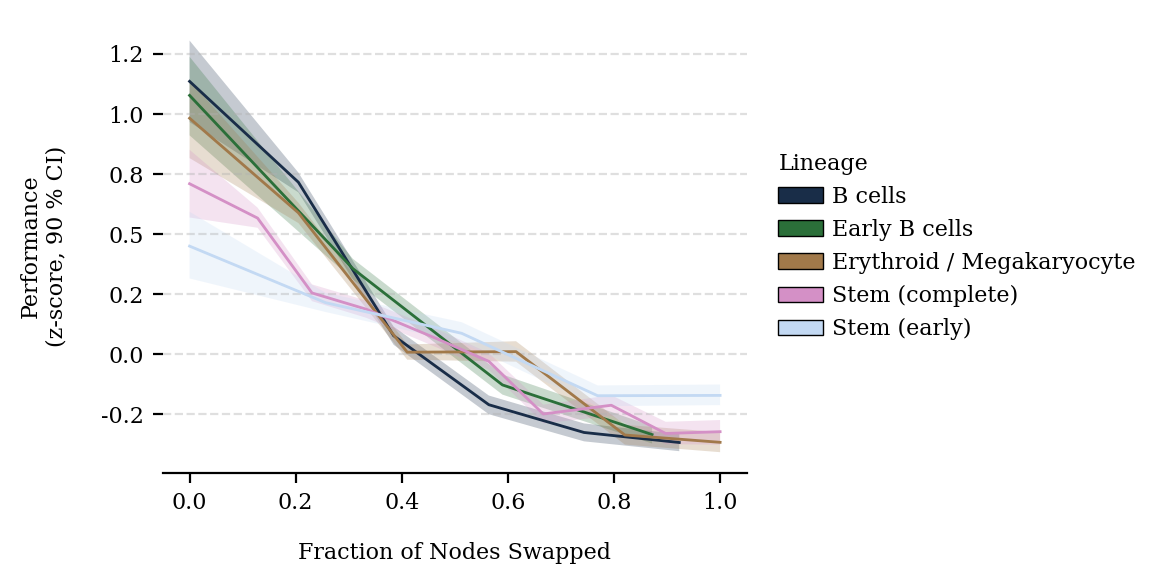

In [156]:
_df_result = df_result.copy()
label_map = {
    "b_cells": "B cells",
    "early_b_cells": "Early B cells",
    "erythroid_megakaryocyte": "Erythroid / Megakaryocyte",
    "complete_stem_trajectory": "Stem (complete)",
    "early_stem_trajectory": "Stem (early)",
}
_df_result["trajectory_name"] = _df_result["trajectory_name"].map(label_map)
_df_result = _df_result.rename(columns={"trajectory_name": "Lineage"})  # legend title

fig, ax = plot_summary_ci(
    _df_result,
    figsize=(7, 3),
    x="scrambling_amount",
    x_label="Fraction of Nodes Swapped",
    ci=0.9,
    line_width=1.01,
    log_x=False,
    hue="Lineage", 
    color = "cubehelix"
)

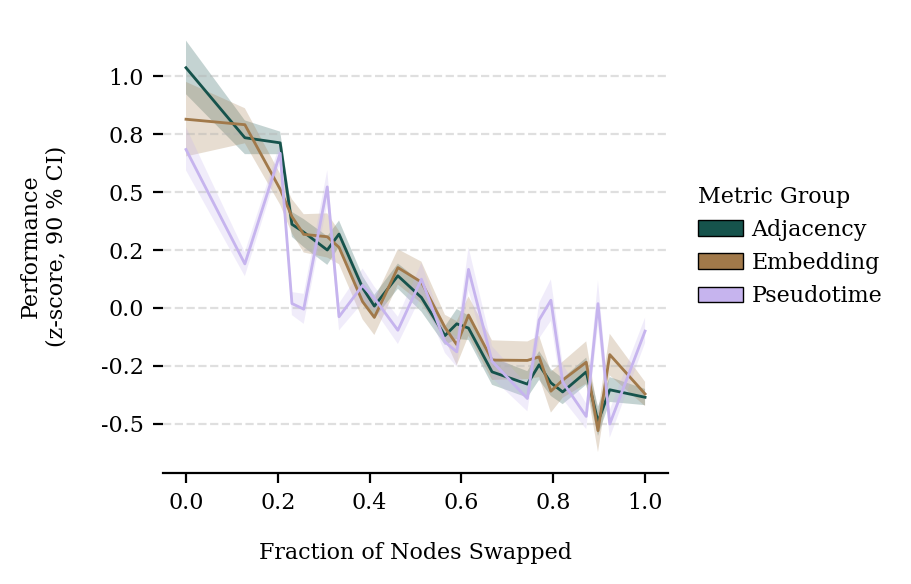

In [157]:
_df_result = df_result.copy()
label_map = {
    "adjacency": "Adjacency",
    "embedding": "Embedding",
    "pseudotime": "Pseudotime",
}
_df_result["path"] = _df_result["path"].map(label_map)
_df_result = _df_result.rename(columns={"path": "Metric Group"})  # legend title

fig, ax = plot_summary_ci(
    _df_result,
    figsize=(5.5, 3),
    x="scrambling_amount",
    x_label="Fraction of Nodes Swapped",
    ci=0.9,
    line_width=1.01,
    log_x=False,
    hue="Metric Group", 
    color = "cubehelix"
)

In [158]:
df_reduced = df_result.pivot(
    index=["trajectory_name", "scrambling_index", "scrambling_amount", "representation", "path"], columns="metric", values="aligned_score"
).mean(axis=1).reset_index(drop=False, inplace=False)
df_reduced.columns = ["trajectory_name", "scrambling_index", "scrambling_amount", "representation", "path", "aligned_score"]

df_reduced = df_reduced.pivot(
    index=["trajectory_name", "scrambling_index", "scrambling_amount", "path"], columns="representation", values="aligned_score"
).mean(axis=1).reset_index(drop=False, inplace=False)
df_reduced.columns = ["trajectory_name", "scrambling_index", "scrambling_amount", "path", "aligned_score"]

In [159]:
df_reduced_t_0, df_reduced_t = list(df_reduced.groupby(["trajectory_name", "path"]))[2]
df_reduced_t = df_reduced_t.sort_values(by=["scrambling_amount"])
print(df_reduced_t_0)

('b_cells', 'pseudotime')


In [160]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def _dec_logistic(x, bottom, top, x0, k):
    """Decreasing logistic (S-curve)."""
    return bottom + (top - bottom) / (1 + np.exp((x - x0) / k))


def fit_decreasing_scurve(
    x, y,
    plot=False,
    ax=None,
    scatter_kw=None,
    line_kw=None,
):
    """
    Fit a decreasing S-curve and *force* the inflection (x0) to sit
    within the observed x-range.

    Returns the same results dict as before; see previous doc-string.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    x_lo, x_hi = np.min(x), np.max(x)

    # ---------- initial guesses -------------------------------
    guess = (
        y.min(),                # bottom
        y.max(),                # top
        np.median(x),           # x0
        (x_hi - x_lo) / 10.0    # k  (>0)
    )

    # ---------- parameter bounds ------------------------------
    # bottom, top  : unbounded
    # x0           : must lie inside data span
    # k            : strictly positive (avoid zero/neg)
    bounds = (
        [-np.inf, -np.inf, x_lo,  1e-12],   # lower
        [ np.inf,  np.inf, x_hi,  np.inf],  # upper
    )

    popt, _ = curve_fit(
        _dec_logistic,
        x, y,
        p0=guess,
        bounds=bounds,
        maxfev=10_000,
    )

    bottom, top, x0, k = popt
    y0 = (top + bottom) / 2.0
    slope = -(top - bottom) / (4.0 * k)

    results = dict(
        bottom=bottom,
        top=top,
        x0=x0,
        y0=y0,
        slope=slope,
        k=k,
        popt=popt,
    )

    # ---------- optional visual -------------------------------
    if plot:
        if ax is None:
            _, ax = plt.subplots(figsize=(6, 4))
        scatter_kw = scatter_kw or dict(s=45, alpha=0.7)
        line_kw = line_kw or dict(lw=2)

        xx = np.linspace(x_lo, x_hi, 400)
        ax.scatter(x, y, **scatter_kw, label="raw")
        ax.plot(xx, _dec_logistic(xx, *popt), **line_kw, label="fit")
        ax.axvline(x0, ls="--", lw=1, label=f"inflection @ {x0:0.3g}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.legend()
        ax.set_title("Decreasing S-curve fit")

    return results



    Bottom asymptote : -0.4554
    Top asymptote    : 1.521
    Inflection point : x = 0.2899, y = 0.5327
    Slope at inflect : -4.396  (negative → decreasing)
    k (steepness)    : 0.1124
    


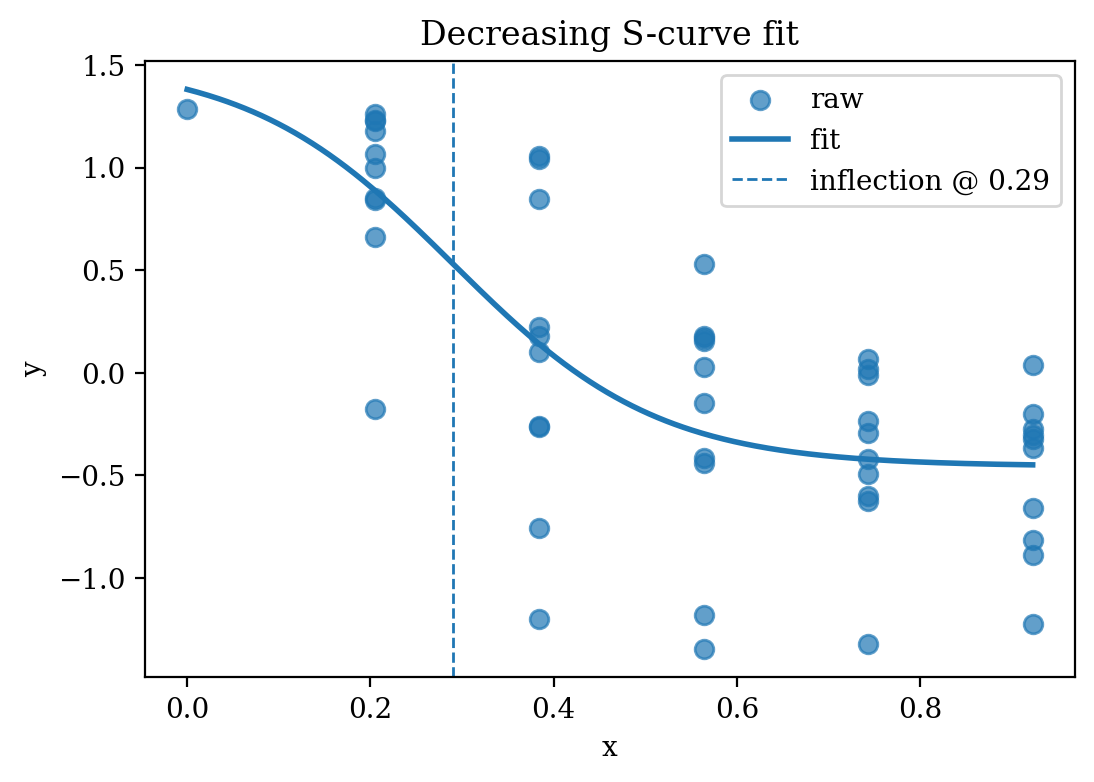

In [161]:
x=list(df_reduced_t["scrambling_amount"])
y=list(df_reduced_t["aligned_score"])

# x, y are your data arrays (1-D, same length)
info = fit_decreasing_scurve(x, y, plot=True)

print(
    f"""
    Bottom asymptote : {info['bottom']:.4g}
    Top asymptote    : {info['top']:.4g}
    Inflection point : x = {info['x0']:.4g}, y = {info['y0']:.4g}
    Slope at inflect : {info['slope']:.4g}  (negative → decreasing)
    k (steepness)    : {info['k']:.4g}
    """
)

In [168]:
_slopes = []
for (i1, i2), df_reduced_t in df_reduced.groupby(["trajectory_name", "path"]):
    steepest_info = fit_decreasing_scurve(list(df_reduced_t["scrambling_amount"]), list(df_reduced_t["aligned_score"]), plot=False)
    steepest_info["trajectory_name"] = i1
    steepest_info["representation"] = i2
    del steepest_info['popt']
    _slopes.append(steepest_info)
slopes = pd.DataFrame(_slopes)
slopes["slope_abs"] = np.abs(slopes["slope"])

In [169]:
label_map = {
    "adjacency": "Adjacency",
    "embedding": "Embedding",
    "pseudotime": "Pseudotime",
}
slopes["representation"] = slopes["representation"].map(label_map)
slopes = slopes.rename(columns={"representation": "Metric Group"})  # legend title

label_map = {
    "b_cells": "B cells",
    "early_b_cells": "Early B cells",
    "erythroid_megakaryocyte": "Erythroid / Megakaryocyte",
    "complete_stem_trajectory": "Stem (complete)",
    "early_stem_trajectory": "Stem (early)",
}
slopes["trajectory_name"] = slopes["trajectory_name"].map(label_map)
slopes = slopes.rename(columns={"trajectory_name": "Lineage"})  # legend title

slopes = slopes.rename(columns={"slope_abs": "Absolute Slope"})  # legend title

slopes

,bottom,top,x0,y0,slope,k,Lineage,Metric Group,Absolute Slope
0,-0.358384,1.375959,2.562482e-01,0.508788,-3.492166,0.124160,B cells,Adjacency,3.492166
1,-0.218596,0.961552,2.436130e-01,0.371478,-2.802160,0.105289,B cells,Embedding,2.802160
2,-0.455402,1.520837,2.899313e-01,0.532717,-4.396445,0.112377,B cells,Pseudotime,4.396445
3,-0.971958,2.834257,1.957521e-14,0.931150,-1.972085,0.482511,Stem (complete),Adjacency,1.972085
4,-1.298974,3.169889,1.152914e-14,0.935457,-1.884880,0.592725,Stem (complete),Embedding,1.884880
5,-0.033207,0.216707,1.912195e-01,0.091750,-2.139253,0.029206,Stem (complete),Pseudotime,2.139253
6,-0.374207,2.190224,1.582376e-10,0.908008,-2.283845,0.280714,Early B cells,Adjacency,2.283845
7,-0.242987,0.956155,2.885074e-01,0.356584,-2.570034,0.116646,Early B cells,Embedding,2.570034
8,-0.562443,1.794910,2.780400e-01,0.616233,-3.163094,0.186317,Early B cells,Pseudotime,3.163094
9,-0.270544,0.994852,2.449633e-01,0.362154,-1.529277,0.206862,Stem (early),Adjacency,1.529277


Standalone colour-bar range → vmin=0.991, vmax=4.396


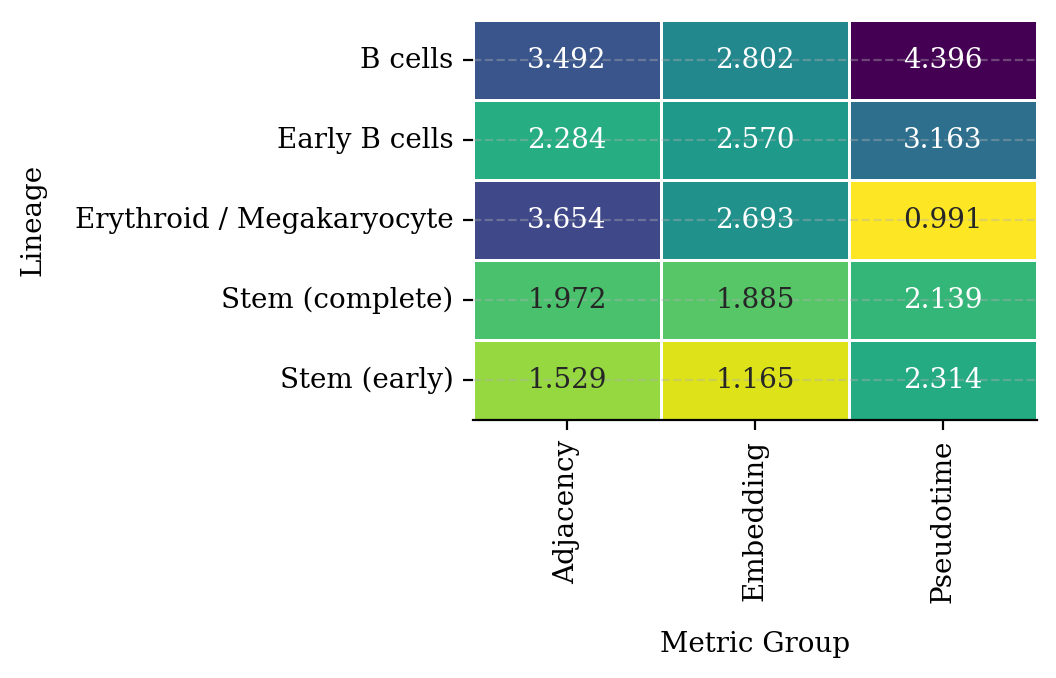

In [185]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── 1. Figure geometry (unchanged) ──────────────────────────────────
row_height = 0.7
col_width  = 1.8
n_rows, n_cols = pivot.shape
fig_height = max(2.5, n_rows * row_height)
fig_width  = max(4.0, n_cols * col_width)

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# ── 2. Compute and print colour range ───────────────────────────────
vmin, vmax = float(np.nanmin(pivot.values)), float(np.nanmax(pivot.values))
print(f"Standalone colour-bar range → vmin={vmin:.3f}, vmax={vmax:.3f}")

# ── 3. Draw heat-map without colour-bar or title ───────────────────
sns.heatmap(
    pivot,
    ax=ax,
    annot=True,
    fmt=".3f",
    cmap="viridis_r",
    linewidths=0.5,
    linecolor="white",
    vmin=vmin,
    vmax=vmax,
    cbar=False            #  ← disables in-plot colour-bar
)

# ── 4. Axis styling (unchanged) ────────────────────────────────────
ax.set_xlabel("Metric Group", fontsize=10, labelpad=10)
ax.set_ylabel("Lineage",      fontsize=10, labelpad=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  ha='right',  fontsize=10)

sns.despine(left=True, bottom=False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


In [195]:
from matplotlib import ticker

def create_vertical_colorbar(
    label,
    vmin=2.5,
    vmax=3.5,
    cmap='plasma',
    fontsize=10,
    n_ticks=5,
    fig_height=4,
    fig_width=1,
    scale=1.0
):
    """
    Creates and displays a standalone vertical colorbar.

    Parameters:
    - label:        str, label for the colorbar
    - vmin, vmax:   float, data range
    - cmap:         str, colormap name
    - fontsize:     int, for label & tick labels
    - n_ticks:      int, approx number of ticks to show
    - fig_height:   float, base height in inches
    - fig_width:    float, base width in inches
    - scale:        float, scale factor for overall size
    """
    # 1) Make the ScalarMappable
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    # 2) New figure, scaled
    fig = plt.figure(figsize=(fig_width * scale, fig_height * scale))
    # you can tweak these numbers if you want more/less padding
    cax = fig.add_axes([0.2, 0.05, 0.3, 0.9])

    # 3) Draw the colorbar
    cbar = fig.colorbar(
        sm,
        cax=cax,
        orientation='vertical'
    )

    # 4) Automatic “nice” locators + re‐draw
    cbar.locator = ticker.MaxNLocator(nbins=n_ticks)
    cbar.update_ticks()

    # 5) Force one‐decimal formatting
    cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    # 6) Label & style
    cbar.set_label(label, fontsize=fontsize)
    cbar.ax.tick_params(labelsize=fontsize)

    plt.show()

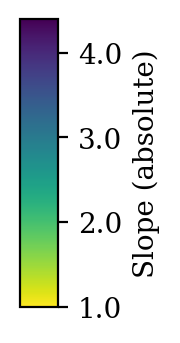

In [199]:
create_vertical_colorbar("Slope (absolute)", cmap="viridis_r", n_ticks=4, fig_height=2, fig_width=0.8, scale=0.8, fontsize=10, vmin=0.991, vmax=4.396)

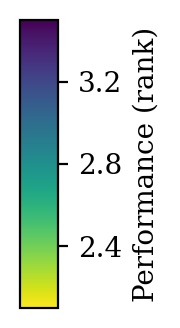

In [201]:
# for the bootstrap lineage plot in the figure2 of hdca
create_vertical_colorbar("Performance (rank)", cmap="viridis_r", n_ticks=4, fig_height=2, fig_width=0.8, scale=0.8, fontsize=10, vmin=2.1, vmax=3.5)